<p style="align: center;"><img align=center src="https://drive.google.com/uc?export=view&id=1aS4vX-ucDKBmZmZMrBwgjl_DvLAadX2C" width=900/></p>


<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

# Домашнее задание. RAG.

В этом домашнем задании вам предстоит создать туристический RAG, провести EDA и проявить креатив! :)

Вам дан набор данных, содержащий информацию о памятниках, архитектуре и других значимых местах. В данных есть:
* название достопримечательности;
* идентификатор на WikiData;
* город расположения;
* координаты долготы и широты;
* описание (извлеченное из WikiData);
* изображение в формате base64;
* сгенерированное описание изображения (генерация с помощью модели BLIP).

Некоторые из памятников могут встречаться несколько раз, но с различными изображениями, из которых не все могут быть качественными. Для компенсации этого даны текстовые описания.

Часть данных взята с Национальной технологической олимпиады студентов по CV. Базовое решение предполагает использование мультимодального ru-CLIP. Но в данном домашнем задании предлагается решить эту задачу творчески, используя NLP подход.

## Установка и импорт библиотек

In [1]:
!pip install -q gdown torch transformers accelerate bitsandbytes langchain sentence-transformers faiss-cpu openpyxl datasets langchain-community ragatouille umap-learn

In [2]:
!pip uninstall langchain langchain-community -y
!pip install langchain==0.1.0 langchain-community==0.0.10 langchain-core==0.1.0
!pip install ragatouille==0.0.8
!pip install pynvml

Found existing installation: langchain 0.1.20
Uninstalling langchain-0.1.20:
  Successfully uninstalled langchain-0.1.20
Found existing installation: langchain-community 0.0.38
Uninstalling langchain-community-0.0.38:
  Successfully uninstalled langchain-community-0.0.38
  Using cached langchain-0.1.0-py3-none-any.whl.metadata (13 kB)
  Using cached langchain_community-0.0.10-py3-none-any.whl.metadata (7.3 kB)
  Using cached langchain_core-0.1.0-py3-none-any.whl.metadata (977 bytes)
INFO: pip is looking at multiple versions of langchain to determine which version is compatible with other requirements. This could take a while.
ERROR: Cannot install langchain-core==0.1.0 and langchain==0.1.0 because these package versions have conflicting dependencies.

The conflict is caused by:
    The user requested langchain-core==0.1.0
    langchain 0.1.0 depends on langchain-core<0.2 and >=0.1.7

To fix this you could try to:
1. loosen the range of package versions you've specified
2. remove packag

In [3]:
import gdown
import pandas as pd
from tqdm.notebook import tqdm
from typing import Optional, List, Tuple
import matplotlib.pyplot as plt
from langchain_core.documents import Document as LangchainDocument
from langchain_community.vectorstores import FAISS
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores.utils import DistanceStrategy
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, pipeline
import numpy as np
import plotly.express as px
import torch
import base64
from PIL import Image
from io import BytesIO
import warnings
warnings.filterwarnings('ignore')

/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


## Загрузка данных (4 балла)

In [10]:
import gdown
import pandas as pd

file_id = "1xC7RSMxhDu-QSfW7YF2dg5O5GbCII-g9"

# Скачиваем файл
gdown.download(f"https://drive.google.com/uc?id={file_id}", "data.csv", quiet=False)

data = pd.read_csv('data.csv')

print(f" Размер данных: {len(data)} записей")
print(f" Колонки: {list(data.columns)}")

Downloading...
From (original): https://drive.google.com/uc?id=1xC7RSMxhDu-QSfW7YF2dg5O5GbCII-g9
From (redirected): https://drive.google.com/uc?id=1xC7RSMxhDu-QSfW7YF2dg5O5GbCII-g9&confirm=t&uuid=f8f6056c-cb4f-49c6-a8a1-c188dee19b5b
To: /content/data.csv
100%|██████████| 672M/672M [00:09<00:00, 67.8MB/s]


 Размер данных: 14634 записей
 Колонки: ['Unnamed: 0', 'Name', 'WikiData', 'City', 'Lon', 'Lat', 'description', 'image', 'en_txt']


In [11]:
data.head()

,Unnamed: 0,Name,WikiData,City,Lon,Lat,description,image,en_txt
0,0,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there are two people that are standing on a tr...
1,1,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed building with a blue and white exterior...
2,2,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a blue and white building with a cloc...
3,3,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a blue and white building with a cloc...
4,4,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a boat that is in the water near a bu...


In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14634 entries, 0 to 14633
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   14634 non-null  int64  
 1   Name         14634 non-null  object 
 2   WikiData     12078 non-null  object 
 3   City         14634 non-null  object 
 4   Lon          14634 non-null  float64
 5   Lat          14634 non-null  float64
 6   description  12078 non-null  object 
 7   image        14634 non-null  object 
 8   en_txt       14634 non-null  object 
dtypes: float64(2), int64(1), object(6)
memory usage: 1.0+ MB


Для декодирования изображений, закодированных в формате base64, можно использовать следующий код:

In [13]:
import base64
import requests
import matplotlib.pyplot as plt
from PIL import Image
import PIL
from io import BytesIO

In [14]:
def get_image(data):
  image = Image.open(BytesIO(base64.b64decode(data))).convert('RGB')
  return image

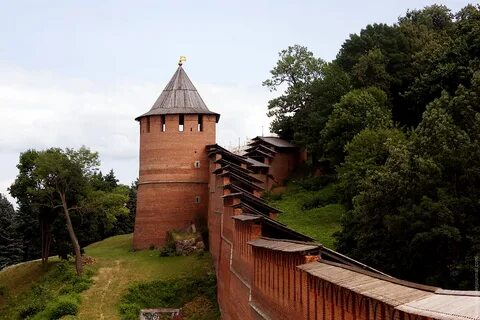

In [15]:
get_image(data.sample(1)['image'].tolist()[0])

В данных есть выбросы — записи, не относящихся к туристическим или историческим объектам. Для очистки данных можно, например, использовать алгоритм TF-IDF: создаем корпус текстов из описаний, применяем TF-IDF, извлекаем наиболее редко или часто встречающиеся слова. Они могут указывать на мусорные данные, такие как мемы, баннеры или личные фото людей. После выделения подозрительных паттернов, можно провести ручную проверку и фильтрацию данных.

Для дальнейшего тестирования и получения чистых сэмплов, рекомендуется взять не менее 100 чистых образцов со стратификацией по городу и названию места. Это можно сделать, выбрав случайным образом несколько образцов из каждой категории (город + название места), чтобы обеспечить равномерное представительство и разнообразие данных.

**!! Важно:** Помните, что чистые сэмплы одного и того же места выдадут примерно одинаковое описание. Есть несколько стратегий, как повысить разнообразие ответов:

- выбор одного самого лучшего:
  - самое длинное описание
  - смое подходящие по мнению LLM
- конкатенация описаний (но важно не сконкатенировать слишком много)

Изображения можно отдать в мета-данные.

In [16]:
# установка и импорт для TF-IDF
!pip install -q scikit-learn

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from collections import Counter
import re

Создаем корпус из описанийизображений (en_txt) и описаний достопримечательностей (description)

In [17]:
# Объединяем текстовые поля для анализа
data['combined_text'] = data['en_txt'].fillna('') + ' ' + data['description'].fillna('')

# Смотрим на размер корпуса
print(f"Количество документов: {len(data['combined_text'])}")
print(f"Пример комбинированного текста:\n{data['combined_text'].iloc[0][:300]}...")

Количество документов: 14634
Пример комбинированного текста:
there are two people that are standing on a track in a stadium спорткомплекс в Екатеринбурге...


TF-IDF

In [18]:
# Настройка векторизатора TF-IDF
tfidf_vectorizer = TfidfVectorizer(
    max_features=1000,  # Ограничим количество признаков для обозримости
    stop_words='english',  # Убираем стоп-слова
    ngram_range=(1, 2)  # Учитываем униграммы и биграммы
)

# Преобразуем тексты в TF-IDF матрицу
tfidf_matrix = tfidf_vectorizer.fit_transform(data['combined_text'])

print(f"Размер TF-IDF матрицы: {tfidf_matrix.shape}")
print(f"Количество признаков (слов): {len(tfidf_vectorizer.get_feature_names_out())}")

Размер TF-IDF матрицы: (14634, 1000)
Количество признаков (слов): 1000


Анализируем частоту слов

In [19]:
# Получаем средние значения TF-IDF для каждого слова
mean_tfidf = np.array(tfidf_matrix.mean(axis=0)).flatten()
feature_names = tfidf_vectorizer.get_feature_names_out()

# Создаем словарь
word_scores = dict(zip(feature_names, mean_tfidf))

# Самые "сильные" слова (высокий TF-IDF)
top_words = sorted(word_scores.items(), key=lambda x: x[1], reverse=True)[:50]

print("\nТоп-50 слов с наивысшим TF-IDF:")
for word, score in top_words[:20]:
    print(f"  {word}: {score:.4f}")


Топ-50 слов с наивысшим TF-IDF:
  building: 0.0532
  arafed: 0.0496
  large: 0.0343
  view: 0.0321
  clock: 0.0315
  екатеринбурге: 0.0299
  white: 0.0286
  ярославле: 0.0283
  arafed view: 0.0281
  church: 0.0276
  tower: 0.0258
  man: 0.0248
  green: 0.0246
  building clock: 0.0212
  clock tower: 0.0207
  храм: 0.0204
  statue: 0.0194
  roof: 0.0187
  white building: 0.0186
  large building: 0.0180


Кластеризация

In [20]:
n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(tfidf_matrix)

# Размеры кластеров
cluster_sizes = pd.Series(cluster_labels).value_counts().sort_index()
print("\nРазмеры кластеров:")
for cluster, size in cluster_sizes.items():
    print(f"  Кластер {cluster}: {size} записей ({size/len(data)*100:.1f}%)")


Размеры кластеров:
  Кластер 0: 2387 записей (16.3%)
  Кластер 1: 1785 записей (12.2%)
  Кластер 2: 9034 записей (61.7%)
  Кластер 3: 873 записей (6.0%)
  Кластер 4: 555 записей (3.8%)


Анализ кластеров

In [21]:
# Смотрим статистику по кластерам
for cluster_id in sorted(set(cluster_labels)):
    cluster_mask = cluster_labels == cluster_id
    cluster_data = data[cluster_mask]

    print(f"\n--- Кластер {cluster_id} ({len(cluster_data)} записей) ---")
    print(f"  Города: {dict(cluster_data['City'].value_counts())}")
    print(f"  Средняя длина description: {cluster_data['description'].str.len().mean():.0f} символов")
    print(f"  Содержит 'arafed': {cluster_data['combined_text'].str.contains('arafed', case=False).sum()} записей")

    # Примеры из кластера
    sample = cluster_data.sample(min(2, len(cluster_data)))
    for idx, row in sample.iterrows():
        print(f"  Пример: {row['Name']} - {row['description']}")


--- Кластер 0 (2387 записей) ---
  Города: {'Ярославль': 1325, 'Нижний Новгород': 439, 'Владимир': 350, 'Екатеринбург': 273}
  Средняя длина description: 30 символов
  Содержит 'arafed': 1770 записей
  Пример: Успенский собор - кафедральный собор в Ярославле
  Пример: Храм Архангела Михаила - Церковь Михаила Архангела

--- Кластер 1 (1785 записей) ---
  Города: {'Екатеринбург': 502, 'Нижний Новгород': 469, 'Ярославль': 411, 'Владимир': 403}
  Средняя длина description: 30 символов
  Содержит 'arafed': 771 записей
  Пример: Крестовоздвиженская церковь (Екатеринбург) - Крестовоздвиженская церковь (Екатеринбург)
  Пример: Екатеринбургский завод - металлургический завод (XVIII век)

--- Кластер 2 (9034 записей) ---
  Города: {'Владимир': 2546, 'Ярославль': 2391, 'Екатеринбург': 2177, 'Нижний Новгород': 1920}
  Средняя длина description: 34 символов
  Содержит 'arafed': 3037 записей
  Пример: №34 Дом контор - Дом контор
  Пример: Уральская государственная консерватория - высшее учебное зав

# Создание чистого датасета

In [22]:
clean_data = data.copy()

print(f" Исходный размер данных: {len(clean_data)} записей")

# удаляем записи с пустыми или слишком короткими описаниями
min_desc_length = 20
clean_data = clean_data[clean_data['description'].str.len() > min_desc_length]
print(f"После фильтрации description: {len(clean_data)} записей")

# удаляем записи с пустыми или слишком короткими en_txt
clean_data = clean_data[clean_data['en_txt'].str.len() > min_desc_length]
print(f"После фильтрации en_txt: {len(clean_data)} записей")

# удаляем записи с нулевыми координатами
clean_data = clean_data[(clean_data['Lon'] != 0) & (clean_data['Lat'] != 0)]
print(f"После фильтрации координат: {len(clean_data)} записей")
print(f"\nОсталось очистки: {len(clean_data)} записей")

 Исходный размер данных: 14634 записей
После фильтрации description: 9746 записей
После фильтрации en_txt: 9745 записей
После фильтрации координат: 9745 записей

Осталось очистки: 9745 записей


Теперь создаем выборку для каждой достопримечательности берем лучший образец(с самым длинным описанием)

In [23]:
# Группируем по городу и названию
grouped = clean_data.groupby(['City', 'Name'])

print(f"Количество уникальных достопримечательностей: {len(grouped)}")
def select_best_sample(group):
    group = group.copy()
    group['desc_len'] = group['description'].str.len()
    group['en_len'] = group['en_txt'].str.len()
    group = group.sort_values(['desc_len', 'en_len'], ascending=False)
    return group.iloc[0]
# Применяем к каждой группе
best_samples = grouped.apply(select_best_sample).reset_index(drop=True)

print(f"{len(best_samples)} лучших образцов")
# Распределение по городам
print(f"\nРаспределение по городам:")
for city, count in best_samples['City'].value_counts().items():
    print(f"  {city}: {count} ({count/len(best_samples)*100:.1f}%)")

Количество уникальных достопримечательностей: 259
259 лучших образцов

Распределение по городам:
  Екатеринбург: 86 (33.2%)
  Нижний Новгород: 81 (31.3%)
  Ярославль: 68 (26.3%)
  Владимир: 24 (9.3%)


Создаем выборку

In [24]:
# Стратификация
final_samples = []
city_counts = best_samples['City'].value_counts()

for city in city_counts.index:
    city_data = best_samples[best_samples['City'] == city]
    n = max(1, int(100 * city_counts[city] / len(best_samples)))
    n = min(n, len(city_data))
    sampled = city_data.sample(n=n, random_state=42)
    final_samples.append(sampled)
    print(f"{city}: взято {n} из {len(city_data)}")

final_dataset = pd.concat(final_samples).reset_index(drop=True)

# Если получилось больше 100, обрезаем до 100
if len(final_dataset) > 100:
    final_dataset = final_dataset.sample(n=100, random_state=42).reset_index(drop=True)

# Если меньше 100, добавляем случайные
if len(final_dataset) < 100:
    remaining = best_samples[~best_samples.index.isin(final_dataset.index)]
    extra = remaining.sample(n=100-len(final_dataset), random_state=42)
    final_dataset = pd.concat([final_dataset, extra]).reset_index(drop=True)

print(f"\nвыборка: {len(final_dataset)} записей")
print(f"\nРаспределение по городам")
for city, count in final_dataset['City'].value_counts().items():
    print(f"  {city}: {count} ({count/len(final_dataset)*100:.1f}%)")

Екатеринбург: взято 33 из 86
Нижний Новгород: взято 31 из 81
Ярославль: взято 26 из 68
Владимир: взято 9 из 24

выборка: 100 записей

Распределение по городам
  Екатеринбург: 33 (33.0%)
  Нижний Новгород: 31 (31.0%)
  Ярославль: 27 (27.0%)
  Владимир: 9 (9.0%)


Здесь предлагаем вам построить RAG с использованием моделей, которые не были представлены на семинаре (включая другие векторные базы данных). Можно воспользоваться материалами по этой ссылке: [data_connection/vectorstores](https://python.langchain.com/v0.1/docs/modules/data_connection/vectorstores/).

!Важно, не забудьте отранжировать чанки текстов с помощью `ragatouille`. На практике порядок текстов в промпте влияет на точность ответа.

Подготовка документов

In [25]:
from langchain_core.documents import Document as LangchainDocument

def create_documents(final_dataset):
    documents = []

    for idx, row in final_dataset.iterrows():
        content = f"""
        Название: {row['Name']}
        Город: {row['City']}
        Описание: {row['description']}
        Описание изображения: {row['en_txt']}
        """

        metadata = {
            "name": row['Name'],
            "city": row['City'],
            "wiki_id": row['WikiData'],
            "latitude": row['Lat'],
            "longitude": row['Lon']
        }

        doc = LangchainDocument(page_content=content, metadata=metadata)
        documents.append(doc)

    return documents

documents = create_documents(final_dataset)

Создание эмбеддингов и векторной базы данных

In [26]:
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_community.vectorstores.utils import DistanceStrategy

embeddings_model = HuggingFaceEmbeddings(
    model_name="intfloat/multilingual-e5-large-instruct",
    model_kwargs={'device': 'cuda' if torch.cuda.is_available() else 'cpu'},
    encode_kwargs={'normalize_embeddings': True}
)

vector_store = FAISS.from_documents(
    documents=documents,
    embedding=embeddings_model,
    distance_strategy=DistanceStrategy.COSINE
)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/128 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_xlm-roberta_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/690 [00:00<?, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

Настройка ранжировщика Ragatouille

In [27]:
import transformers
import torch.optim as optim
transformers.AdamW = optim.AdamW
from ragatouille import RAGPretrainedModel

reranker = RAGPretrainedModel.from_pretrained("colbert-ir/colbertv2.0")
def retrieve_and_rerank(query, vector_store, reranker, k=10):
    # Получаем больше документов для переранжирования
    initial_docs = vector_store.similarity_search(query, k=k*2)

    # Подготавливаем документы для ColBERT
    documents_text = [doc.page_content for doc in initial_docs]

    # Переранжируем с помощью ColBERT
    reranked_results = reranker.rerank(query, documents_text, k=k)

    # Возвращаем переранжированные документы
    final_docs = [initial_docs[idx] for idx in reranked_results]

    return final_docs

artifact.metadata: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/405 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Настройка языковой модели

In [30]:
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
import torch

model_name = "Qwen/Qwen2.5-1.5B-Instruct"

print("Загрузка токенизатора...")
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)

print("Загрузка модели...")
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True
)

pipe = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    max_new_tokens=256,
    temperature=0.7,
    do_sample=True
)


Загрузка токенизатора...


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Device set to use cuda:0


Выполните визуализацию эмбеддингов при помощи метода главных компонент (PCA) и Uniform Manifold Approximation and Projection (UMAP). Пожалуйста, выполните PCA независимо от pacmap.


1. Подготовка текстов документов...
   Количество документов: 100

2. Создание эмбеддингов...
   Размер матрицы эмбеддингов: (100, 1024)

3. Подготовка метаданных...
   Города: ['Владимир', 'Екатеринбург', 'Нижний Новгород', 'Ярославль']

4. Применение PCA...
   Объясненная дисперсия PC1: 0.112
   Объясненная дисперсия PC2: 0.069
   Суммарная объясненная дисперсия: 0.181

5. Применение UMAP...

6. Создание графиков...


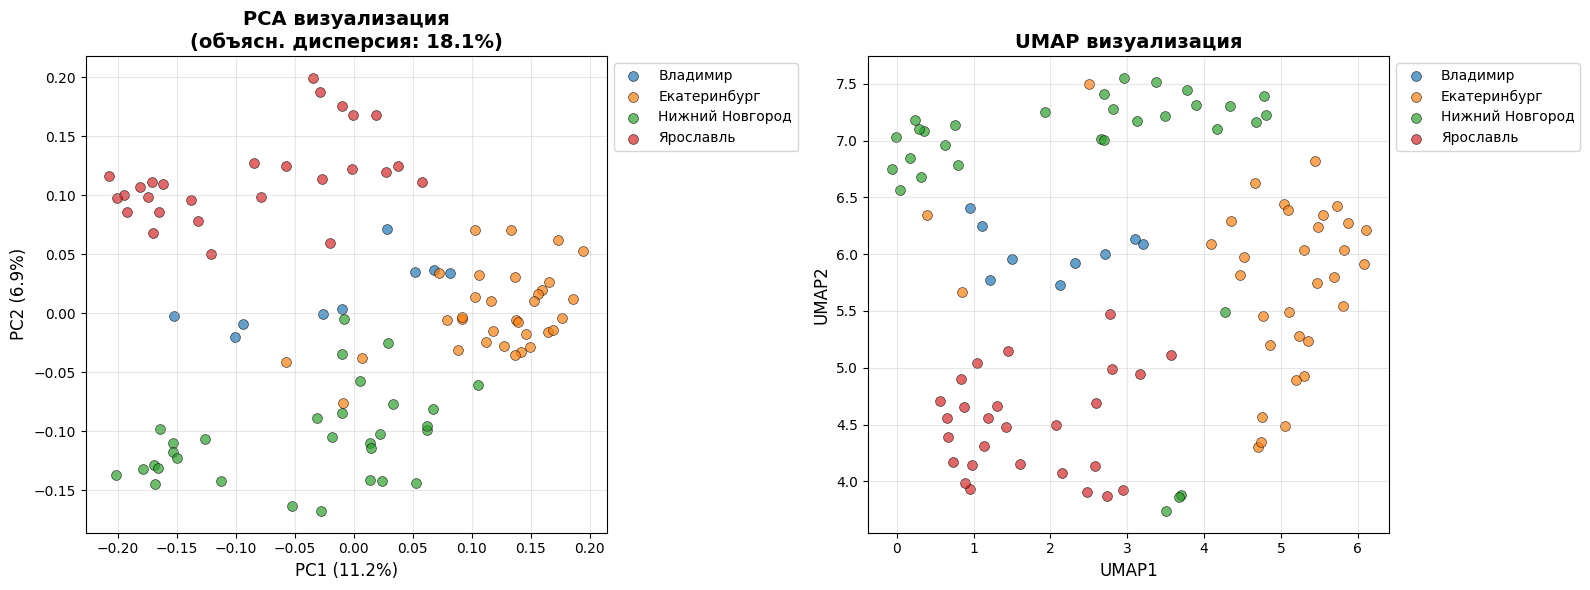


7. Статистика по городам:
----------------------------------------
   Владимир: 9 документов (9.0%)
   Екатеринбург: 33 документов (33.0%)
   Нижний Новгород: 31 документов (31.0%)
   Ярославль: 27 документов (27.0%)


In [31]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import umap

def visualize_embeddings(documents, embeddings_model):

    print("\n1. Подготовка текстов документов...")
    texts = [doc.page_content for doc in documents]
    print(f"   Количество документов: {len(texts)}")

    print("\n2. Создание эмбеддингов...")
    embeddings = embeddings_model.embed_documents(texts)
    embeddings_array = np.array(embeddings)
    print(f"   Размер матрицы эмбеддингов: {embeddings_array.shape}")

    print("\n3. Подготовка метаданных...")
    cities = [doc.metadata['city'] for doc in documents]
    unique_cities = sorted(set(cities))

    # Создаем словарь для цветов
    city_to_color = {city: i for i, city in enumerate(unique_cities)}
    colors = [city_to_color[city] for city in cities]

    print(f"   Города: {unique_cities}")

    # PCA
    print("\n4. Применение PCA...")
    pca = PCA(n_components=2, random_state=42)
    pca_result = pca.fit_transform(embeddings_array)

    # объясненная дисперсия
    explained_variance = pca.explained_variance_ratio_
    print(f"   Объясненная дисперсия PC1: {explained_variance[0]:.3f}")
    print(f"   Объясненная дисперсия PC2: {explained_variance[1]:.3f}")
    print(f"   Суммарная объясненная дисперсия: {sum(explained_variance):.3f}")

    # UMAP
    print("\n5. Применение UMAP...")
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=15,      # количество соседей
        min_dist=0.1,        # минимальное расстояние между точками
        random_state=42,
        metric='cosine'       # метрика расстояния
    )
    umap_result = reducer.fit_transform(embeddings_array)

    print("\n6. Создание графиков...")
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Цветовая схема для городов
    cmap = plt.cm.tab10

    # PCA визуализация
    ax1 = axes[0]
    for i, city in enumerate(unique_cities):
        mask = np.array(cities) == city
        ax1.scatter(
            pca_result[mask, 0],
            pca_result[mask, 1],
            c=[cmap(i)],
            label=city,
            alpha=0.7,
            s=50,
            edgecolors='black',
            linewidth=0.5
        )

    ax1.set_title(f'PCA визуализация\n(объясн. дисперсия: {sum(explained_variance):.1%})',
                  fontsize=14, fontweight='bold')
    ax1.set_xlabel(f'PC1 ({explained_variance[0]:.1%})', fontsize=12)
    ax1.set_ylabel(f'PC2 ({explained_variance[1]:.1%})', fontsize=12)
    ax1.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=10)
    ax1.grid(True, alpha=0.3)

    # UMAP визуализация
    ax2 = axes[1]
    for i, city in enumerate(unique_cities):
        mask = np.array(cities) == city
        ax2.scatter(
            umap_result[mask, 0],
            umap_result[mask, 1],
            c=[cmap(i)],
            label=city,
            alpha=0.7,
            s=50,
            edgecolors='black',
            linewidth=0.5
        )

    ax2.set_title('UMAP визуализация', fontsize=14, fontweight='bold')
    ax2.set_xlabel('UMAP1', fontsize=12)
    ax2.set_ylabel('UMAP2', fontsize=12)
    ax2.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=10)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Вывод статистики
    print("\n7. Статистика по городам:")
    print("-" * 40)
    for city in unique_cities:
        count = cities.count(city)
        print(f"   {city}: {count} документов ({count/len(cities)*100:.1f}%)")
    return pca_result, umap_result, cities

pca_result, umap_result, cities = visualize_embeddings(documents, embeddings_model)

# RAGAS (3 балла)

RAGAS - это система, созданная для автоматической оценки эффективности модели RAG. Она представляет собой комплексный инструмент, способный оценить как качество извлечения информации, так и качество созданного текста. Это достигается благодаря использованию различных метрик, которые анализируют разные аспекты ответов, сгенерированных языковой моделью.



## Метрики оценки в RAGAS

### Faithfulness
Оценивает, насколько ответы языковой модели верно передают информацию, содержащуюся в источниках данных. Это критически важно, чтобы гарантировать, что модель не искажает или не меняет информацию при её интерпретации.

---

$
Faithfulness = \frac{\text{|Number of claims that can be inferred from given context|}}{\text{|Total number of claims in the generated answer|}}
$

### Answer Relevancy
Демонстрирует, насколько ответы соответствуют заданным вопросам. Это важный аспект, так как даже правильный ответ с технической точки зрения может быть ненужным, если он не отвечает на конкретный вопрос пользователя.

---

$\text{answer relevancy} = \frac{1}{N} \sum_{i=1}^{N} cos(E_{g_i}, E_o)$

$\text{answer relevancy} = \frac{1}{N} \sum_{i=1}^{N} \frac{E_{g_i} \cdot E_o}{\|E_{g_i}\|\|E_o\|}$

Где:

* $E_{g_i}$ - это эмбеддинг сгенерированного ответа $i$

* $E_o$ - это эмбеддинг исходного вопроса.

* $N$ - это количество сгенерированных вопросов, которое по умолчанию равно 3.

### Context Recall и Context Precision
Эти метрики измеряют эффективность модели в учете контекста вопроса для формирования ответа. "Context Recall" оценивает количество использованной информации из контекста в ответе, в то время как "Context Precision" оценивает точность и релевантность использования контекстной информации.

---

* $ \text{context recall} = \frac{\text{|GT sentences that can be attributed to context|}}{\text{|Number of sentences in GT|}} $
* $Context Precision@k = \frac{\sum \text{precision@k}}{\text{total number of relevant items in the top K results}}$
  * $Precision@k = \frac{\text {true positives@k}}{\text{(true positives@k + false positives@k)}}$

### Answer Semantic Similarity
Оценивает степень семантической близости между ответом модели и эталонным ответом. Это позволяет определить, насколько естественно и точно модель способна воссоздавать человеческий язык.

### Answer Correctness
Оценка корректности ответа. Это последний шаг в проверке, чтобы убедиться, предоставляет ли модель точную и достоверную информацию в своем ответе.

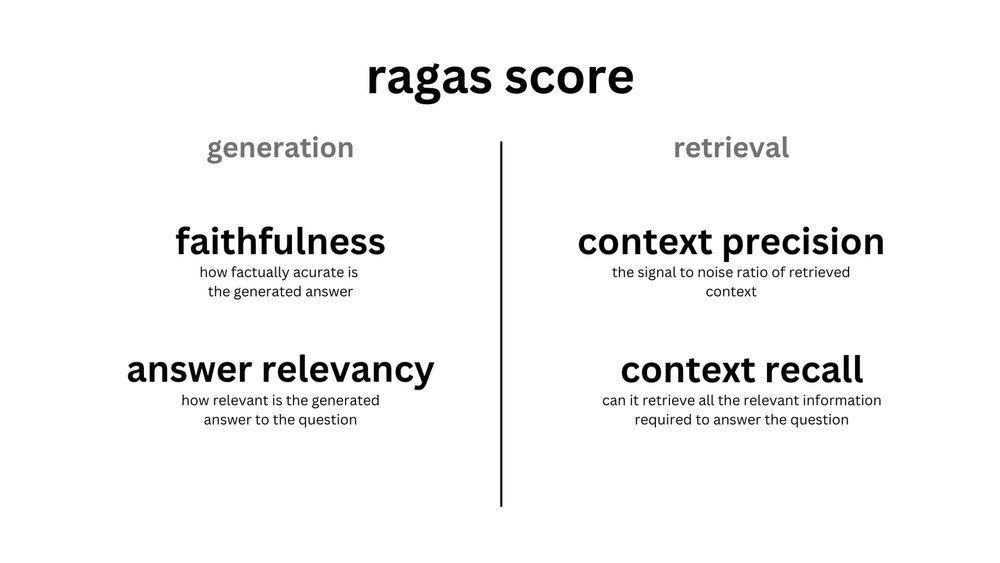

В этом задании вам нужно реализовать метрику answer_relevancy в коде. Опционально за допбаллы можно реализовать другие метрики.

Для этого датасет нужно привести к виду, в котором будут следующие поля:

### 1. question
- Смысл: Эта колонка содержит вопросы, на которые нужно найти ответы. В контексте задач QA, это основная информация, которую модель должна обработать для генерации ответа.
- Пример: "Каковы преимущества RAG?"

### 2. ground_truths
- Смысл: В этой колонке находятся правильные ответы на соответствующие вопросы. Это может использоваться для оценки производительности модели, так как позволяет сравнить сгенерированные ответы с эталонными.
- Пример: "RAG улучшает качество генерации, используя внешние источники информации."

### 3. answer
- Смысл: Эта колонка содержит ответы, которые генерирует модель на основе заданных вопросов. Это может быть результат работы модели, которую вы тестируете или обучаете.
- Пример: "RAG позволяет моделям извлекать информацию из внешних источников, что улучшает их способность отвечать на сложные вопросы."

### 4. contexts
- Смысл: Эта колонка предоставляет контекст или дополнительную информацию, которая может быть полезна для понимания вопроса или для формирования ответа. Это может быть текст, из которого был извлечен ответ, или другие релевантные документы.
- Пример: "RAG (Retrieval-Augmented Generation) — это метод, который использует внешние базы данных для получения информации при генерации текста."

HINT: Поле question можно тоже сгенерировать. Например, можно попросить модель задать вопрос по описанию изображения.

HINT: Для answer_relevancy нужны не все поля

HINT: Инференс такого эксперимента может быть долгим. План минимум: возьмите 100 случайных сэмплов.

Подготовка данных для RAGAS

In [50]:
def data_preprocess(test_sample, retriever_func, n_samples=20) -> pd.DataFrame:
    results = []

    for idx, row in test_sample.head(n_samples).iterrows():
        # Генерируем вопрос на основе названия и города
        question = f"Что можно рассказать о достопримечательности '{row['Name']}' в городе {row['City']}?"

        # Используем существующее описание
        ground_truth = f"{row['Name']}. {row['description']} {row['en_txt']}".strip()

        # Поиск контекстов через RAG ретривер
        try:
            retrieved = retriever_func(question, top_k=3)
            contexts = [r['text'] for r in retrieved]
        except Exception as e:
            print(f"Ошибка при поиске: {e}")
            contexts = ["Документы не найдены"]

        # Генерируем ответ
        if contexts and contexts[0] != "Документы не найдены":
            answer = contexts[0][:500]
        else:
            answer = "Информация о данной достопримечательности не найдена."

        results.append({
            'question': question,
            'ground_truths': [ground_truth],
            'answer': answer,
            'contexts': contexts
        })

    return pd.DataFrame(results)

In [51]:
def answer_relevancy(question: str, answer: str, embeddings_model) -> float:
    # Разбиваем ответ на предложения
    sentences = answer.replace('?', '.').replace('!', '.').split('.')
    sentences = [s.strip() for s in sentences if len(s.strip()) > 15]

    # Берем N=3 предложения
    n_generations = min(3, len(sentences))

    if n_generations == 0:
        # Если ответ слишком короткий, используем сам ответ
        generated_questions = [f"Что такое {answer[:50]}?"]
        n_generations = 1
    else:
        # Превращаем утверждения в вопросы
        generated_questions = []
        for s in sentences[:n_generations]:
            # Формируем вопрос
            if s.lower().startswith(('the', 'a', 'an')):
                question_text = f"Что такое {s}?"
            else:
                question_text = s
            generated_questions.append(question_text)

    # Все тексты для эмбеддингов
    all_texts = [question] + generated_questions

    # Получаем эмбеддинги
    embeddings = embeddings_model.embed_documents(all_texts)
    embeddings = np.array(embeddings)

    # Нормализуем векторы
    norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
    norms = np.where(norms == 0, 1, norms)  # Защита от деления на ноль
    embeddings = embeddings / norms

    # Эмбеддинг исходного вопроса
    emb_original = embeddings[0]

    # Эмбеддинги сгенерированных вопросов
    emb_generated = embeddings[1:]

    # Вычисляем косинусное сходство
    similarities = []
    for emb_gen in emb_generated:
        similarity = np.dot(emb_original, emb_gen)
        similarities.append(similarity)

    # Финальный score: среднее по всем сгенерированным вопросам
    score = np.mean(similarities) if similarities else 0.0

    # Нормализуем от 0 до 1
    score = max(0.0, min(1.0, score))

    return float(score)


def answer_relevancy_batch(questions: List[str], answers: List[str], embeddings_model) -> tuple:
    scores = []

    for question, answer in zip(questions, answers):
        score = answer_relevancy(question, answer, embeddings_model)
        scores.append(score)

    overall_score = np.mean(scores) if scores else 0.0

    return overall_score, scores

# Протестируйте ваш RAG (3 балла)

In [53]:
def generate_question(row, pipe):
    """Генерирует вопрос для достопримечательности"""
    prompt = f"""На основе следующей информации о достопримечательности, составь один информативный вопрос:
    Название: {row['Name']}
    Город: {row['City']}
    Описание: {row['description']}

    Вопрос:"""

    messages = [
        {"role": "user", "content": prompt}
    ]

    response = pipe(messages, max_new_tokens=100, temperature=0.7)[0]['generated_text'][-1]['content']
    return response.strip()


def get_rag_answer(question, vector_store, reranker, pipe, top_k=5):
    # Поиск релевантных документов
    docs = vector_store.similarity_search(question, k=top_k)

    if not docs:
        return "Информация не найдена", []

    # Подготовка контекста
    contexts = []
    contexts_text = []
    for doc in docs:
        contexts.append(doc)
        contexts_text.append(doc.page_content)

    # Переранжирование через reranker
    if reranker and len(contexts_text) > 1:
        try:
            reranked = reranker.rerank(question, contexts_text, k=min(3, len(contexts_text)))
            contexts = [docs[idx] for idx in reranked]
            contexts_text = [contexts_text[idx] for idx in reranked]
        except Exception as e:
            print(f"Reranker error: {e}")

    # Формирование промпта для генерации ответа
    context_str = "\n\n".join(contexts_text[:3])
    prompt = f"""Используя следующую информацию, ответь на вопрос.

Информация:
{context_str}

Вопрос: {question}

Ответ (будь краток и информативен):"""

    messages = [
        {"role": "user", "content": prompt}
    ]

    response = pipe(messages, max_new_tokens=256, temperature=0.7)[0]['generated_text'][-1]['content']

    return response.strip(), contexts[:3]


def test_ragas_pipeline(final_dataset, embeddings_model, pipe, vector_store, reranker, n_samples=5):
    # Подготовка данных
    test_samples = min(n_samples, len(final_dataset))
    sample_data = final_dataset.sample(n=test_samples, random_state=42)

    ragas_data = []
    questions = []
    answers = []
    contexts_list = []
    ground_truths_list = []

    print(f"\n[1/3] Подготовка данных ({test_samples} сэмплов)...")

    for idx, (_, row) in enumerate(sample_data.iterrows()):
        # Генерация вопроса
        question = generate_question(row, pipe)
        questions.append(question)

        # Ground truth
        ground_truth = f"{row['description']}. {row['en_txt']}".strip()
        ground_truths_list.append([ground_truth])

        # Получение ответа через RAG
        answer, contexts = get_rag_answer(question, vector_store, reranker, pipe)
        answers.append(answer)
        contexts_list.append([doc.page_content for doc in contexts])

        ragas_data.append({
            'question': question,
            'ground_truths': [ground_truth],
            'answer': answer,
            'contexts': [doc.page_content for doc in contexts]
        })

        # Вывод каждого сэмпла
        print(f"\n{'─' * 80}")
        print(f"    СЭМПЛ {idx+1}: {row['Name']} ({row['City']})")
        print(f"{'─' * 80}")
        print(f"    ВОПРОС:")
        print(f"    {question[:200]}{'...' if len(question) > 200 else ''}")
        print(f"\n    ОТВЕТ:")
        print(f"    {answer[:200]}{'...' if len(answer) > 200 else ''}")

    # Создаем DataFrame
    ragas_df = pd.DataFrame(ragas_data)

    # Расчет Answer Relevancy
    print(f"\n\n[2/3] Расчет метрики Answer Relevancy...")

    relevancy_scores = []
    for i, (q, a) in enumerate(zip(questions, answers)):
        score = answer_relevancy(q, a, embeddings_model)
        relevancy_scores.append(score)
        print(f"    Вопрос {i+1}: {score:.3f}")

    overall_relevancy = np.mean(relevancy_scores)

    # Вывод статистики
    print(f"\n    Количество вопросов:              {len(relevancy_scores)}")
    print(f"    Средняя релевантность:            {overall_relevancy:.3f}")
    print(f"    Минимальная релевантность:        {min(relevancy_scores):.3f}")
    print(f"    Максимальная релевантность:       {max(relevancy_scores):.3f}")
    print(f"    Стандартное отклонение:           {np.std(relevancy_scores):.3f}")

    # Оценка качества
    quality = "ОТЛИЧНО" if overall_relevancy > 0.8 else "ХОРОШО" if overall_relevancy > 0.6 else "ТРЕБУЕТ УЛУЧШЕНИЯ"
    print(f"\n    ОБЩАЯ ОЦЕНКА: {quality}")
    return ragas_df, overall_relevancy, relevancy_scores

In [54]:
# Функция для получения эмбеддинга
def get_embedding(text, embeddings_model):
    return embeddings_model.embed_query(text)

# Запуск тестирования
ragas_results, overall_rel, rel_scores = test_ragas_pipeline(
    final_dataset=final_dataset,
    embeddings_model=embeddings_model,
    pipe=pipe,
    vector_store=vector_store,
    reranker=reranker,
    n_samples=5
)

print(f"\nРезультаты Answer Relevancy:")
print(f"  Средняя релевантность: {overall_rel:.3f}")
print(f"  Результаты по запросам: {rel_scores}")


[1/3] Подготовка данных (5 сэмплов)...


100%|██████████| 1/1 [00:00<00:00, 53.13it/s]


Reranker error: list indices must be integers or slices, not dict

────────────────────────────────────────────────────────────────────────────────
    СЭМПЛ 1: Петровский монастырь (Ярославль) (Ярославль)
────────────────────────────────────────────────────────────────────────────────
    ВОПРОС:
    В каком городе находится Петропавловский монастырь?

    ОТВЕТ:
    Петропавловский монастырь расположен в Ярославле.


100%|██████████| 1/1 [00:00<00:00, 48.24it/s]


Reranker error: list indices must be integers or slices, not dict

────────────────────────────────────────────────────────────────────────────────
    СЭМПЛ 2: Губернаторский сад (Нижний Новгород)
────────────────────────────────────────────────────────────────────────────────
    ВОПРОС:
    Какой исторический комплекс включает в себя Губернаторский сад в Нижнем Новгороде?

    ОТВЕТ:
    Нижегородский Кремль.


...

Reranker error: list indices must be integers or slices, not dict

────────────────────────────────────────────────────────────────────────────────
    СЭМПЛ 3: Ярославский камерный театр (Ярославль)
────────────────────────────────────────────────────────────────────────────────
    ВОПРОС:
    Какое название имеет камерный театр в городе Ярославле?

    ОТВЕТ:
    Ярославский камерный театр


100%|██████████| 1/1 [00:00<00:00, 24.91it/s]


Reranker error: list indices must be integers or slices, not dict

────────────────────────────────────────────────────────────────────────────────
    СЭМПЛ 4: Церковь Александра Невского в Сормово (Нижний Новгород)
────────────────────────────────────────────────────────────────────────────────
    ВОПРОС:
    В чем уникальность и особенности Церкви Александра Невского в Сормово?

    ОТВЕТ:
    Церковь Александра Невского в Сормово имеет чередование белого и черного цвета, что является уникальным элементом ее архитектурного дизайна. Этот технический прием придает ей особое очарование и выдел...


100%|██████████| 1/1 [00:00<00:00, 71.49it/s]


Reranker error: list indices must be integers or slices, not dict

────────────────────────────────────────────────────────────────────────────────
    СЭМПЛ 5: Локомотив (Нижний Новгород)
────────────────────────────────────────────────────────────────────────────────
    ВОПРОС:
    В каком городе находится многоцелевой стадион "Локомотив"?

    ОТВЕТ:
    Нижний Новгород


[2/3] Расчет метрики Answer Relevancy...
    Вопрос 1: 0.934
    Вопрос 2: 0.879
    Вопрос 3: 0.931
    Вопрос 4: 0.880
    Вопрос 5: 0.865

    Количество вопросов:              5
    Средняя релевантность:            0.898
    Минимальная релевантность:        0.865
    Максимальная релевантность:       0.934
    Стандартное отклонение:           0.029

    ОБЩАЯ ОЦЕНКА: ОТЛИЧНО

Результаты Answer Relevancy:
  Средняя релевантность: 0.898
  Результаты по запросам: [0.9339972476342768, 0.8787494312266967, 0.9308770929794707, 0.8803219541493252, 0.8649049109926145]


# Дополнительная часть (+3 балла)

Реализуйте одну из метрик retrieval-части на выбор.

Для того, чтобы понять model as a judge подход из RAGAS, советуем посетить [этот кукбук](https://huggingface.co/learn/cookbook/en/rag_evaluation)

In [57]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from typing import List, Tuple

def get_embedding(text: str, embeddings_model) -> np.ndarray:
    return np.array(embeddings_model.embed_query(text[:500]))  # ограничиваем длину


def context_precision(questions: List[str], contexts_list: List[List[str]],
                      embeddings_model,
                      similarity_threshold: float = 0.5) -> Tuple[float, List[float]]:
    precision_scores = []

    for i, (question, contexts) in enumerate(zip(questions, contexts_list)):

        if len(contexts) == 0:
            precision_scores.append(0.0)
            continue

        # Эмбеддинг вопроса
        q_emb = get_embedding(question, embeddings_model)

        # Получаем эмбеддинги контекстов
        ctx_embeddings = [get_embedding(ctx, embeddings_model) for ctx in contexts]

        # Вычисляем similarity каждого контекста с вопросом
        similarities = [cosine_similarity([q_emb], [ctx_emb])[0][0] for ctx_emb in ctx_embeddings]

        # Оцениваем релевантность каждого контекста
        relevant_at_k = [sim > similarity_threshold for sim in similarities]

        # Вычисляем precision@k для релевантных документов
        precisions_for_relevant = []
        for j, is_relevant in enumerate(relevant_at_k):
            if is_relevant:
                tp_at_j = sum(relevant_at_k[:j+1])
                precisions_for_relevant.append(tp_at_j / (j+1))

        if precisions_for_relevant:
            context_precision_score = np.mean(precisions_for_relevant)
        else:
            context_precision_score = 0.0

        precision_scores.append(context_precision_score)

        # Отладочный вывод
        print(f"  Вопрос {i+1}: similarities={[f'{s:.3f}' for s in similarities]}, "
              f"relevant={relevant_at_k}, precision={context_precision_score:.3f}")

    overall_precision = np.mean(precision_scores) if precision_scores else 0.0
    return overall_precision, precision_scores


def context_recall(questions: List[str], contexts_list: List[List[str]],
                   embeddings_model,
                   similarity_threshold: float = 0.5) -> Tuple[float, List[float]]:
    recall_scores = []

    for i, (question, contexts) in enumerate(zip(questions, contexts_list)):

        if len(contexts) == 0:
            recall_scores.append(0.0)
            continue

        # Эмбеддинг вопроса
        q_emb = get_embedding(question, embeddings_model)

        # Получаем эмбеддинги контекстов
        ctx_embeddings = [get_embedding(ctx, embeddings_model) for ctx in contexts]

        # Вычисляем similarity каждого контекста с вопросом
        similarities = [cosine_similarity([q_emb], [ctx_emb])[0][0] for ctx_emb in ctx_embeddings]

        # Считаем релевантные контексты
        relevant_count = sum(1 for sim in similarities if sim > similarity_threshold)

        # Recall = доля релевантных контекстов от общего числа (или от ожидаемого числа)
        # Ожидаем, что хотя бы 1 контекст будет релевантен
        expected_relevant = 1  # минимум 1 релевантный контекст
        recall = min(1.0, relevant_count / expected_relevant)

        recall_scores.append(recall)

        print(f"  Вопрос {i+1}: relevant={relevant_count}/{len(contexts)}, recall={recall:.3f}")

    overall_recall = np.mean(recall_scores) if recall_scores else 0.0
    return overall_recall, recall_scores


def test_retrieval_metrics(final_dataset, embeddings_model, pipe, vector_store, reranker, n_samples=5):
    test_samples = min(n_samples, len(final_dataset))
    sample_data = final_dataset.sample(n=test_samples, random_state=42)

    questions = []
    contexts_list = []

    print(f"\nПодготовка данных ({test_samples} сэмплов)...")

    for idx, (_, row) in enumerate(sample_data.iterrows()):
        # Генерируем вопрос
        question = generate_question(row, pipe)
        questions.append(question)

        # Получаем контексты через RAG
        answer, contexts = get_rag_answer(question, vector_store, reranker, pipe)
        contexts_list.append([doc.page_content for doc in contexts])

        print(f"СЭМПЛ {idx+1}: {row['Name']} ({row['City']})")
        print(f"ВОПРОС: {question[:150]}...")
        print(f"КОНТЕКСТ 1: {contexts[0].page_content[:100]}..." if contexts else "Нет контекстов")

    # Context Precision с разными порогами
    thresholds = [0.4, 0.5, 0.6]

    for th in thresholds:
        overall_precision, precision_scores = context_precision(
            questions=questions,
            contexts_list=contexts_list,
            embeddings_model=embeddings_model,
            similarity_threshold=th
        )
        print(f"\n>>> Context Precision (threshold={th}): {overall_precision:.3f}\n")

    # Используем порог 0.5 как основной
    overall_precision, precision_scores = context_precision(
        questions=questions,
        contexts_list=contexts_list,
        embeddings_model=embeddings_model,
        similarity_threshold=0.5
    )

    overall_recall, recall_scores = context_recall(
        questions=questions,
        contexts_list=contexts_list,
        embeddings_model=embeddings_model,
        similarity_threshold=0.5
    )

    # Вывод итогов
    print(f"Средняя Context Precision:    {overall_precision:.3f}")
    print(f"Средняя Context Recall:       {overall_recall:.3f}")

    f1_score = 2 * (overall_precision * overall_recall) / (overall_precision + overall_recall) if (overall_precision + overall_recall) > 0 else 0
    print(f"\nF1-score (retrieval):         {f1_score:.3f}")

    quality = "ОТЛИЧНО" if f1_score > 0.7 else "ХОРОШО" if f1_score > 0.5 else "ТРЕБУЕТ УЛУЧШЕНИЯ"
    print(f"\nОБЩАЯ ОЦЕНКА КАЧЕСТВА RETRIEVAL: {quality}")
    return overall_precision, overall_recall, f1_score


# Запуск тестирования
precision, recall, f1 = test_retrieval_metrics(
    final_dataset=final_dataset,
    embeddings_model=embeddings_model,
    pipe=pipe,
    vector_store=vector_store,
    reranker=reranker,
    n_samples=5
)


Подготовка данных (5 сэмплов)...


100%|██████████| 1/1 [00:00<00:00, 41.93it/s]


Reranker error: list indices must be integers or slices, not dict
СЭМПЛ 1: Петровский монастырь (Ярославль) (Ярославль)
ВОПРОС: В каком городе находится Петровский монастырь?...
КОНТЕКСТ 1: 
        Название: Петровский монастырь (Ярославль)
        Город: Ярославль
        Описание: Петро...


100%|██████████| 1/1 [00:00<00:00, 50.24it/s]


Reranker error: list indices must be integers or slices, not dict
СЭМПЛ 2: Губернаторский сад (Нижний Новгород)
ВОПРОС: В каком городе находится Губернаторский сад?...
КОНТЕКСТ 1: 
        Название: Губернаторский сад
        Город: Нижний Новгород
        Описание: парк в Нижего...


...

Reranker error: list indices must be integers or slices, not dict
СЭМПЛ 3: Ярославский камерный театр (Ярославль)
ВОПРОС: Какая известная оперетта в Ярославском камерном театре?...
КОНТЕКСТ 1: 
        Название: Ярославский камерный театр
        Город: Ярославль
        Описание: Ярославский...


100%|██████████| 1/1 [00:00<00:00, 39.06it/s]


Reranker error: list indices must be integers or slices, not dict
СЭМПЛ 4: Церковь Александра Невского в Сормово (Нижний Новгород)
ВОПРОС: Вопрос: Какая известная церковь находится в городе Нижний Новгород и как ее называют?...
КОНТЕКСТ 1: 
        Название: Церковь во имя Всемилостивейшего Спаса
        Город: Нижний Новгород
        Опи...


100%|██████████| 1/1 [00:00<00:00, 62.87it/s]


Reranker error: list indices must be integers or slices, not dict
СЭМПЛ 5: Локомотив (Нижний Новгород)
ВОПРОС: В каком городе находится многоцелевой стадион "Локомотив"?...
КОНТЕКСТ 1: 
        Название: Локомотив
        Город: Нижний Новгород
        Описание: многоцелевой стадион в...
  Вопрос 1: similarities=['0.873', '0.852', '0.846'], relevant=[True, True, True], precision=1.000
  Вопрос 2: similarities=['0.887', '0.854', '0.840'], relevant=[True, True, True], precision=1.000
  Вопрос 3: similarities=['0.861', '0.843', '0.834'], relevant=[True, True, True], precision=1.000
  Вопрос 4: similarities=['0.893', '0.891', '0.890'], relevant=[True, True, True], precision=1.000
  Вопрос 5: similarities=['0.890', '0.846', '0.823'], relevant=[True, True, True], precision=1.000

>>> Context Precision (threshold=0.4): 1.000

  Вопрос 1: similarities=['0.873', '0.852', '0.846'], relevant=[True, True, True], precision=1.000
  Вопрос 2: similarities=['0.887', '0.854', '0.840'], relevant=[True, 